In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# UK Housing Prices vs. Mortgage Affordability (2005 – 2025)

## 1. Problem Formulation
This project explores the relationship between UK property values and buyer purchasing power. While the **UK House Price Index (HPI)** tracks market prices, the **Bank of England’s Mortgage Lenders and Administrators Statistics (MLAR)** reveals the underlying financial risk and affordability. The goal is to translate this economic problem into a mathematical counterpart to determine if mortgage metrics serve as indicators for house price shifts.

## 2. Project Objectives
* **Data Integration:** Consolidate monthly price data and quarterly lending statistics to demonstrate skills in merging and validating various data types.
* **Exploratory Data Analysis (EDA):** Use analytical graphs and plots to visualize 20-year trends and identify market cycles.
* **Mathematical Analysis:** Apply statistical methods and hypothesis testing to validate the link between lending constraints and price volatility.

## 3. Data Sources
* **HM Land Registry (UKHPI):** The primary source for housing price trends, providing average prices and sales volumes based on completed sales.
* **Bank of England (MLAR):** An independent data source used for mortgage affordability, covering Loan-to-Value (LTV) and Loan-to-Income (LTI) ratios.

## 4. Methodology & Data Ingestion
To analyze the 20-year correlation between prices and mortgage rates, this section automates the ingestion of three primary datasets: **UKHPI** (Market Prices), **BoE** (Mortgage Rates), and **ONS** (Earnings). 

**Technical Approach:**
* **Modular Paths:** A `data_folder` variable is defined to ensure environment portability and easy directory management.
* **Metadata Handling:** The ONS earnings data (`emp.csv`) contains 6 rows of administrative headers (contact details, legal notes, and titles). We use the `skiprows=6` parameter to bypass this metadata and ensure the resulting DataFrame contains only the statistical table.
* **Quality Assurance:** A "Dataset Integrity Check" is performed to verify that record counts and date ranges (2005–2025) are consistent across all sources before the data-merging process begins.


In [2]:
# 1. Setup paths
data_folder = 'data'

# 2. Load the files
house_price_data = pd.read_csv(os.path.join(data_folder, 'ukhpi-united-kingdom-from-2005-01-01-to-2025-12-01.csv'))
mortgage_rate_data = pd.read_csv(os.path.join(data_folder, 'Bank of England  Database.csv'))
employment_data = pd.read_csv(os.path.join(data_folder, 'emp.csv'), skiprows=6)    # skiprows=6 used to remove non-tabular data

# 3. Vetting
print("--- DATASET INTEGRITY CHECK ---")
print(f"HPI Rows:          {house_price_data.shape[0]} rows, {house_price_data.shape[1]} columns")
print(f"Mortgage Rows:     {mortgage_rate_data.shape[0]} rows, {mortgage_rate_data.shape[1]} columns")
print(f"Employment Rows:   {employment_data.shape[0]} rows, {employment_data.shape[1]} columns")

--- DATASET INTEGRITY CHECK ---
HPI Rows:          252 rows, 56 columns
Mortgage Rows:     252 rows, 5 columns
Employment Rows:   887 rows, 459 columns


## 5. Data Cleaning & Feature Engineering
This stage transforms raw data into a standardized format suitable for statistical analysis.

**Key Operations:**
* **Column Standardisation:** Isolates the three core variables — **Average House Price**, **2-year/5-year Fixed Mortgage Rates**, and **Real Weekly Earnings** — from their respective source datasets and renames them to a uniform schema (`avg_house_price`, `rate_2yr`, `rate_5yr`, `real_earnings`). This ensures unambiguous column references throughout all subsequent merging and analysis steps.
* **Temporal Normalisation:** Converts various date formats (e.g., DD-MM-YYYY and YYYY-MM) into a unified `datetime` object.
* **Monthly Anchoring:** All data points are normalised to the **1st of the month** to resolve discrepancies between end-of-month and mid-month reporting cycles.

In [3]:
# 1. Cleaning the Mortgage Rate Data
if 'rate_2yr' not in mortgage_rate_data.columns:
    mortgage_rate_data.rename(columns={
        mortgage_rate_data.columns[0]: 'date',
        mortgage_rate_data.columns[1]: 'rate_2yr',
        mortgage_rate_data.columns[3]: 'rate_5yr'
    }, inplace=True)
    mortgage_rate_data = mortgage_rate_data[['date', 'rate_2yr', 'rate_5yr']]

# 2. Cleaning the House Price Data
if 'avg_house_price' not in house_price_data.columns:
    house_price_data.rename(columns={
        'Period': 'date',
        'Average price All property types': 'avg_house_price'
    }, inplace=True)
    house_price_data = house_price_data[['date', 'avg_house_price']]

# 3. Cleaning the Employment Data
if 'real_earnings' not in employment_data.columns:
    em_headers = pd.read_csv(os.path.join(data_folder, 'emp.csv'), nrows=1).columns.tolist()
    employment_data.columns = em_headers
    earnings_col = [c for c in employment_data.columns if 'Real Terms Level' in str(c) and 'Regular Pay' in str(c)]
    employment_data.rename(columns={
        employment_data.columns[0]: 'date',
        earnings_col[0]: 'real_earnings'
    }, inplace=True)
    employment_data = employment_data[['date', 'real_earnings']]

# 4. Standardize all dates to the 1st of the month
for data in [mortgage_rate_data, house_price_data, employment_data]:
    data['date'] = pd.to_datetime(data['date'], errors='coerce', dayfirst=True)
    data.dropna(subset=['date'], inplace=True)
    data['date'] = data['date'].dt.to_period('M').dt.to_timestamp()

print("--- FINAL VERIFICATION ---")
print(f"Mortgage: {mortgage_rate_data.columns.tolist()}")
print(f"HPI: {house_price_data.columns.tolist()}")
print(f"Earnings: {employment_data.columns.tolist()}")

--- FINAL VERIFICATION ---
Mortgage: ['date', 'rate_2yr', 'rate_5yr']
HPI: ['date', 'avg_house_price']
Earnings: ['date', 'real_earnings']


/var/folders/75/l9c923tx7lq_kr4c7t01qm5c0000gn/T/ipykernel_16037/2002358425.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['date'] = pd.to_datetime(data['date'], errors='coerce', dayfirst=True)


## 6. Data Integration & The Master Merge
This section consolidates the three independent time-series into a single relational dataset to enable cross-variable analysis.

**Technical Strategy:**
* **Relational Joining:** Uses an **Inner Join** between House Prices and Mortgage Rates (2-year and 5-year fixed) to ensure strict temporal alignment — only months present in both datasets are retained.
* **Frequency Synchronisation:** Employs a **Left Join** and **Forward Fill (`ffill`)** on earnings data, capped at 3 consecutive months, to map the lower-frequency ONS series onto the monthly timeline without introducing artificial volatility.
* **Chronological Indexing:** Sorts the master frame by date to maintain the integrity of time-series trends (2005–2025).

In [4]:
# --- CONSOLIDATED WORKFLOW: LOAD, CLEAN, & MERGE ---

# 1. Reloading
data_folder = 'data'
hp_raw = pd.read_csv(os.path.join(data_folder, 'ukhpi-united-kingdom-from-2005-01-01-to-2025-12-01.csv'))
mr_raw = pd.read_csv(os.path.join(data_folder, 'Bank of England  Database.csv'))

# Read true headers from row 0, then reload with skiprows=6
em_headers = pd.read_csv(os.path.join(data_folder, 'emp.csv'), nrows=1).columns.tolist()
em_raw     = pd.read_csv(os.path.join(data_folder, 'emp.csv'), skiprows=6)
em_raw.columns = em_headers

# 2. Cleaning & Renaming
# House Price Data
hp_clean = hp_raw.rename(columns={
    'Period': 'date',
    'Average price All property types': 'avg_house_price'
})[['date', 'avg_house_price']]

# Mortgage Rate Data
mr_clean = mr_raw.rename(columns={
    mr_raw.columns[0]: 'date',
    mr_raw.columns[1]: 'rate_2yr',
    mr_raw.columns[3]: 'rate_5yr'
})[['date', 'rate_2yr', 'rate_5yr']]

# Employment Data
earnings_col = [c for c in em_raw.columns if 'Real Terms Level' in str(c) and 'Regular Pay' in str(c)]
em_clean = em_raw.rename(columns={
    em_raw.columns[0]: 'date',
    earnings_col[0]: 'real_earnings'
})[['date', 'real_earnings']]

# 3. Standartize Data
for df in [hp_clean, mr_clean, em_clean]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)
    df.dropna(subset=['date'], inplace=True)
    df['date'] = df['date'].dt.to_period('M').dt.to_timestamp()

# 4. The Master Merge
# Merge HPI and Mortgage Rates first (monthly)
master_data = pd.merge(hp_clean, mr_clean, on='date', how='inner')

# Merge with Earnings using 'left' to keep all months, then fill the gaps
master_data = pd.merge(master_data, em_clean, on='date', how='left')
master_data['real_earnings'] = master_data['real_earnings'].ffill()

# 5. Final Cleanup
master_data = master_data.sort_values('date').reset_index(drop=True)

print("--- SUCCESS: MONTHLY MASTER DATASET CREATED ---")
print(f"Total Months: {len(master_data)}")
print(master_data.head(15)) # Show first 15 to see the monthly data filling in

--- SUCCESS: MONTHLY MASTER DATASET CREATED ---
Total Months: 252
         date  avg_house_price  rate_2yr  rate_5yr  real_earnings
0  2005-01-01           138759      4.99      5.20          455.0
1  2005-02-01           138626      5.07      5.25          455.0
2  2005-03-01           139763      5.20      5.28          455.0
3  2005-04-01           141751      5.16      5.23          455.0
4  2005-05-01           143273      4.91      5.05          455.0
5  2005-06-01           144410      4.77      4.92          455.0
6  2005-07-01           146269      4.59      4.84          455.0
7  2005-08-01           146864      4.56      4.85          455.0
8  2005-09-01           146635      4.52      4.82          455.0
9  2005-10-01           146342      4.54      4.85          455.0
10 2005-11-01           146777      4.74      4.98          455.0
11 2005-12-01           147580      4.74      5.00          455.0
12 2006-01-01           147360      4.62      4.92          461.0
13 2006-02

/var/folders/75/l9c923tx7lq_kr4c7t01qm5c0000gn/T/ipykernel_16037/2929541431.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)


## 7. Exploratory Data Analysis: House Prices vs. Mortgage Rates
To investigate the core hypothesis, we use a two-panel time-series visualization to compare 
UK property values and fixed mortgage rates across a 20-year period (2005–2025).

**Analytical Focus:**
- **Trend Correlation:** Observing whether sustained periods of low fixed rates correspond 
  to accelerated house price growth, and whether rate spikes produce a cooling effect.
- **Economic Shocks:** Identifying how both variables reacted to three major events — 
  the 2008 Financial Crisis, the COVID-19 pandemic, and the 2022–2023 rate-hike cycle — 
  using shaded bands for direct visual reference.
- **Rate Spread:** The shaded area between the 2-year and 5-year fixed rates in the lower 
  panel highlights periods of curve inversion, which can signal market expectations 
  of future rate changes.

/var/folders/75/l9c923tx7lq_kr4c7t01qm5c0000gn/T/ipykernel_16037/686657846.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


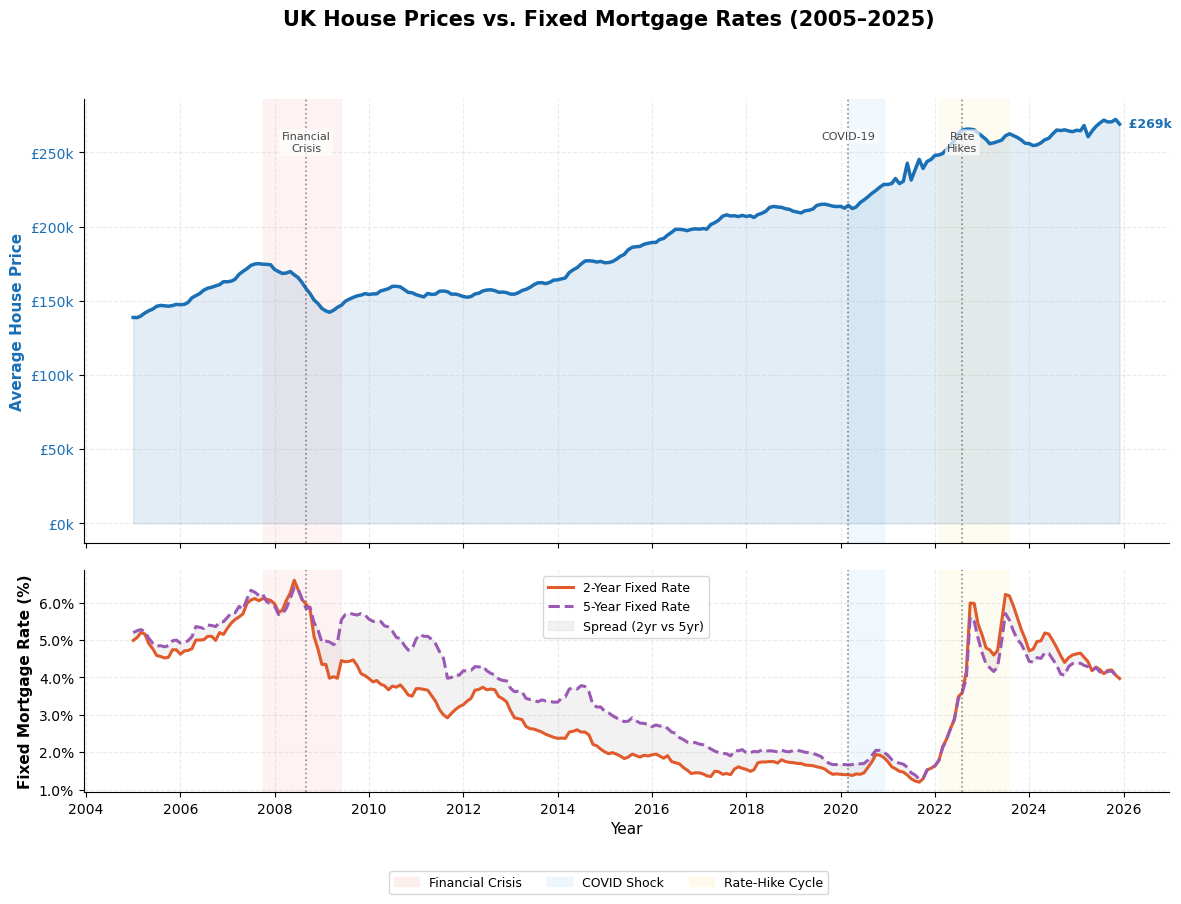

In [19]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
})

COLOR_PRICE = '#1a6fb5'
COLOR_2YR   = '#e05a2b'
COLOR_5YR   = '#9b59b6'

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08},
    sharex=True
)

shock_bands = [
    ('2007-10-01', '2009-06-01', '#fdecea'),
    ('2020-03-01', '2020-12-01', '#e8f4fd'),
    ('2022-02-01', '2023-08-01', '#fef9e7'),
]
for start, end, col in shock_bands:
    for ax in (ax_top, ax_bot):
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=col, alpha=0.6, zorder=0)

ax_top.fill_between(master_data['date'], master_data['avg_house_price'], alpha=0.12, color=COLOR_PRICE)
ax_top.plot(master_data['date'], master_data['avg_house_price'],
            color=COLOR_PRICE, linewidth=2.5, label='Avg House Price')
ax_top.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax_top.set_ylabel('Average House Price', fontsize=11, fontweight='bold', color=COLOR_PRICE)
ax_top.tick_params(axis='y', labelcolor=COLOR_PRICE)

last = master_data.iloc[-1]
ax_top.annotate(f"  £{last['avg_house_price']/1000:.0f}k",
                xy=(last['date'], last['avg_house_price']),
                fontsize=9, color=COLOR_PRICE, va='center', fontweight='bold')

events = {'2008-09-01': 'Financial\nCrisis', '2020-03-01': 'COVID-19', '2022-08-01': 'Rate\nHikes'}
for date_str, label in events.items():
    ed = pd.to_datetime(date_str)
    ax_top.axvline(ed, color='#444', linestyle=':', linewidth=1.2, alpha=0.6)
    ax_top.text(ed, master_data['avg_house_price'].max() * 0.97, label,
                fontsize=8, color='#444', ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))

ax_bot.plot(master_data['date'], master_data['rate_2yr'],
            color=COLOR_2YR, linewidth=2.2, label='2-Year Fixed Rate')
ax_bot.plot(master_data['date'], master_data['rate_5yr'],
            color=COLOR_5YR, linewidth=2.2, linestyle='--', label='5-Year Fixed Rate')
ax_bot.fill_between(master_data['date'], master_data['rate_2yr'], master_data['rate_5yr'],
                    alpha=0.10, color='gray', label='Spread (2yr vs 5yr)')
ax_bot.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax_bot.set_ylabel('Fixed Mortgage Rate (%)', fontsize=11, fontweight='bold')
ax_bot.set_xlabel('Year', fontsize=11)
ax_bot.legend(loc='upper center', frameon=True, fontsize=9)

for date_str in events:
    ax_bot.axvline(pd.to_datetime(date_str), color='#444', linestyle=':', linewidth=1.2, alpha=0.6)

ax_bot.xaxis.set_major_locator(mdates.YearLocator(2))
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

band_patches = [
    mpatches.Patch(color='#fdecea', alpha=0.8, label='Financial Crisis'),
    mpatches.Patch(color='#e8f4fd', alpha=0.8, label='COVID Shock'),
    mpatches.Patch(color='#fef9e7', alpha=0.8, label='Rate-Hike Cycle'),
]
fig.legend(handles=band_patches, loc='lower center', ncol=3,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('UK House Prices vs. Fixed Mortgage Rates (2005–2025)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:**

UK house prices nearly doubled over 20 years, showing remarkable resilience. While the 2008 Financial Crisis caused a 15% decline, the 2022–23 rate-hike cycle—the most aggressive in decades—produced only a ~5% correction. This suggests that current price levels are increasingly decoupled from interest rate sensitivity, likely driven by chronic supply-demand imbalances rather than borrowing costs alone.

## 8. Affordability Analysis: House Price-to-Earnings Ratio

To move beyond raw price levels, we construct a **Price-to-Earnings (PTE) ratio** — a widely used affordability metric that expresses the average house price as a multiple of annual earnings. This normalises price growth against income growth, revealing whether housing has become genuinely less affordable or whether rising prices have been offset by rising wages.

**Calculation:**

$$\text{PTE Ratio} = \frac{\text{Average House Price}}{\text{Real Weekly Earnings} \times 52}$$

A ratio of 10x means the average home costs 10 years of gross salary. The red dashed line marks the 20-year average, providing a baseline to identify periods of above or below average affordability stress.

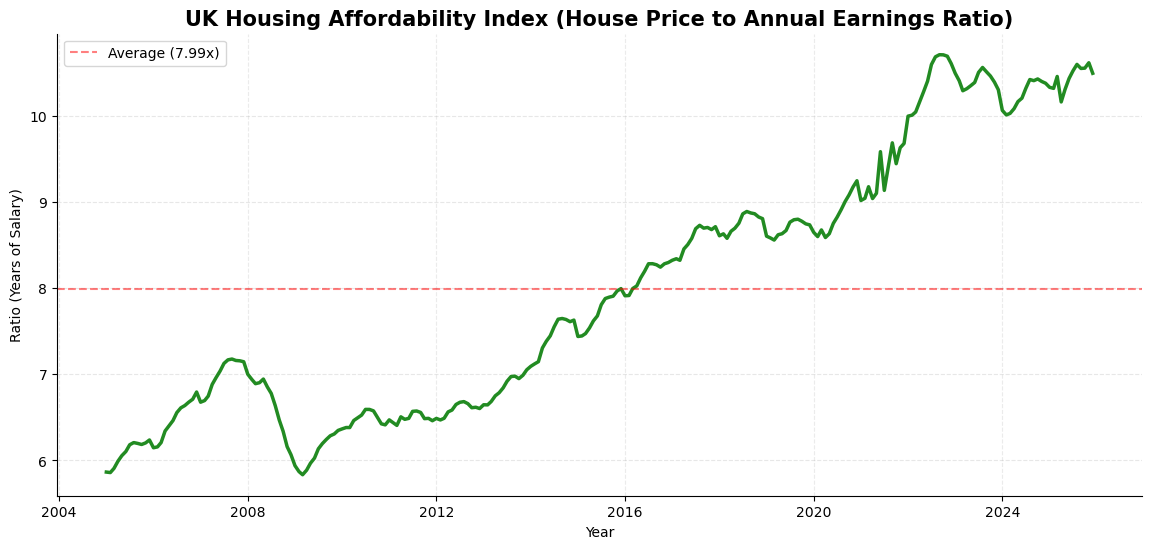

--- AFFORDABILITY KEY STATS ---
Lowest Ratio: 5.83x
Highest Ratio: 10.71x
Current Ratio: 10.50x


In [6]:
# 1. Calculate the Affordability Ratio
# We multiply real_earnings by 52 (because they are usually weekly figures)
master_data['price_to_earnings_ratio'] = master_data['avg_house_price'] / (master_data['real_earnings'] * 52) 

# 2. Create the Affordability Plot
plt.figure(figsize=(14, 6))
plt.plot(master_data['date'], master_data['price_to_earnings_ratio'], color='forestgreen', linewidth=2.5)

# Horizontal line for the average levels
avg_ratio = master_data['price_to_earnings_ratio'].mean()
plt.axhline(avg_ratio, color='red', linestyle='--', alpha=0.5, label=f'Average ({avg_ratio:.2f}x)')

# Styling
plt.title('UK Housing Affordability Index (House Price to Annual Earnings Ratio)', fontsize=15, fontweight='bold')
plt.ylabel('Ratio (Years of Salary)')
plt.xlabel('Year')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Summary Statistics
print("--- AFFORDABILITY KEY STATS ---")
print(f"Lowest Ratio: {master_data['price_to_earnings_ratio'].min():.2f}x")
print(f"Highest Ratio: {master_data['price_to_earnings_ratio'].max():.2f}x")
print(f"Current Ratio: {master_data['price_to_earnings_ratio'].iloc[-1]:.2f}x")

**Observation:**

The PTE ratio has consistently exceeded its 20-year average since 2014, confirming that house price growth has structurally outpaced real wage growth. The 2022 peak represents the least affordable period in the dataset, indicating that the "entry price" for the UK housing market has reached a multiple of income that is historic and potentially unsustainable for first-time buyers.

## 9. Mortgage Stress Analysis: Monthly Repayment as % of Earnings

To quantify affordability at the individual buyer level, we calculate the 
**Mortgage Stress Ratio** — the percentage of monthly gross earnings required 
to service a typical mortgage repayment. Unlike the Price-to-Earnings ratio, 
this metric captures the direct cash-flow pressure on buyers by incorporating 
the actual cost of borrowing.

**Assumptions:**
- **Loan-to-Value (LTV):** 80% — buyer provides a 20% deposit
- **Mortgage Term:** 25 years (standard UK repayment term)
- **Rate Used:** 2-year fixed rate (the most commonly taken product in the UK)
- **Earnings:** Real weekly earnings converted to monthly (× 4.33)

**Monthly Repayment Formula:**

$$M = P \cdot \frac{r(1+r)^n}{(1+r)^n - 1}$$

Where $P$ is the loan principal, $r$ is the monthly interest rate, and $n$ is 
the total number of monthly payments (300 for a 25-year term).

The **30% threshold** (red dashed line) is a widely referenced affordability 
benchmark — households spending more than 30% of gross income on housing are 
considered to be under mortgage stress.

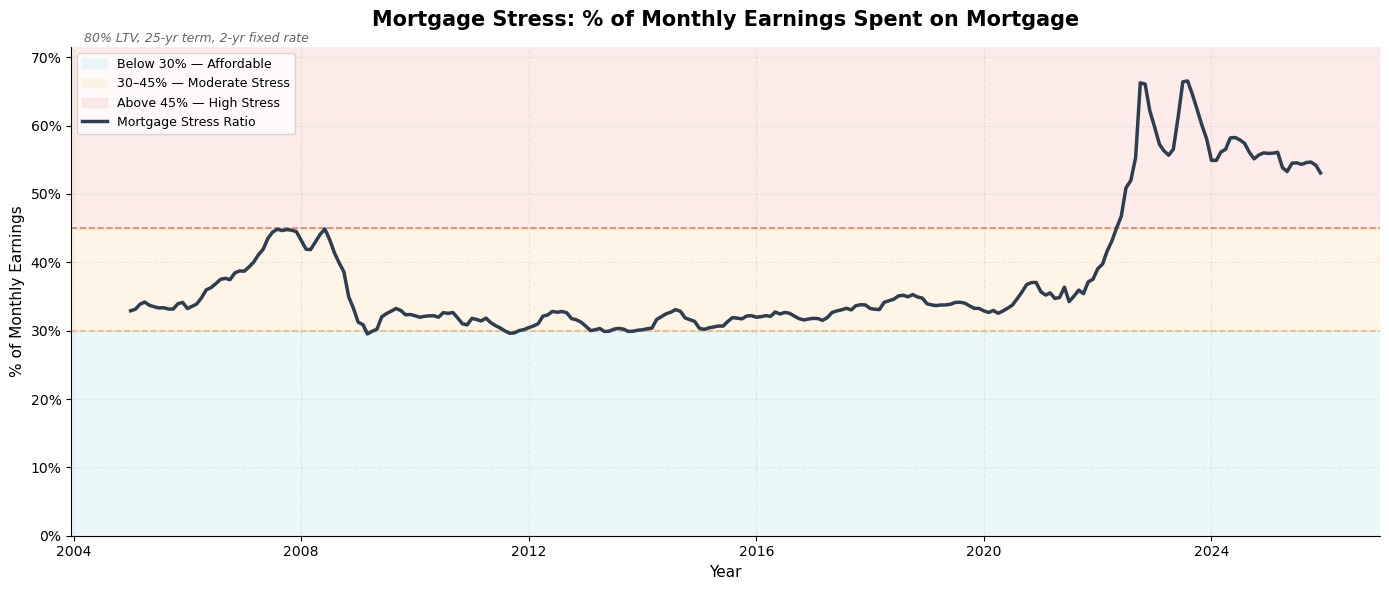

Current Mortgage Stress: 53.1%


In [7]:
# 1. Mortgage Payment Formula
P = master_data['avg_house_price'] * 0.8
r = (master_data['rate_2yr'] / 100) / 12
n = 25 * 12

master_data['monthly_mortgage'] = P * (r * (1 + r)**n) / ((1 + r)**n - 1)

# 2. Monthly Earnings
master_data['monthly_earnings'] = master_data['real_earnings'] * 4.33

# 3. Mortgage-to-Income Ratio (%)
master_data['mortgage_stress_ratio'] = (master_data['monthly_mortgage'] / master_data['monthly_earnings']) * 100

# 4. Plot
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Zone shading
ax.axhspan(0,  30, color='#d4f1f4', alpha=0.45, zorder=0, label='Below 30% — Affordable')
ax.axhspan(30, 45, color='#fde9c9', alpha=0.45, zorder=0, label='30–45% — Moderate Stress')
ax.axhspan(45, 90, color='#fad4cc', alpha=0.45, zorder=0, label='Above 45% — High Stress')

# Zone threshold lines
ax.axhline(30, color='#F4A24B', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
ax.axhline(45, color='#E05A2B', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)

# Main line
ax.plot(master_data['date'], master_data['mortgage_stress_ratio'],
        color='#2c3e50', linewidth=2.5, zorder=3, label='Mortgage Stress Ratio')

# Styling
ax.set_title('Mortgage Stress: % of Monthly Earnings Spent on Mortgage',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('% of Monthly Earnings', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_ylim(0, max(master_data['mortgage_stress_ratio'].max() + 5, 70))
ax.grid(axis='y', alpha=0.2, zorder=1)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.annotate('80% LTV, 25-yr term, 2-yr fixed rate',
            xy=(0.01, 1.01), xycoords='axes fraction',
            fontsize=9, color='#666', style='italic')

ax.legend(loc='upper left', frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

print(f"Current Mortgage Stress: {master_data['mortgage_stress_ratio'].iloc[-1]:.1f}%")

**Observation:**

Between 2010 and 2021, historically low interest rates "masked" the impact of rising house prices by keeping monthly repayments below the 30% stress threshold. The 2022 rate surge broke this trend, pushing repayments sharply into the "Stress Zone." This reveals that affordability is no longer just an asset-price problem, but a cash-flow crisis for the modern borrower.

## 10. UK Housing Hardship Index

To synthesise the combined effect of house prices, mortgage rates, and earnings 
into a single comparable metric, we construct a **Housing Hardship Index**. 
This composite index captures the overall financial burden of homeownership 
relative to income, normalised so that **2005 = 100** as the base year.

**Formula:**

$$\text{Hardship Index} = \frac{\text{Average House Price} \times \text{2-Year Rate}_{(\%/100)}}{\text{Real Weekly Earnings}} \times \frac{100}{\text{Base Value}_{2005}}$$

**How to read it:**
- A score of **100** represents the affordability conditions in 2005
- A score of **150** means homeownership is **50% harder** than in 2005
- A score above **120** is classified as a **High Stress** zone in this analysis

Unlike the Price-to-Earnings ratio (which ignores borrowing costs) and the 
Mortgage Stress ratio (which ignores price levels), the Hardship Index 
simultaneously captures both price and rate pressure relative to earnings.

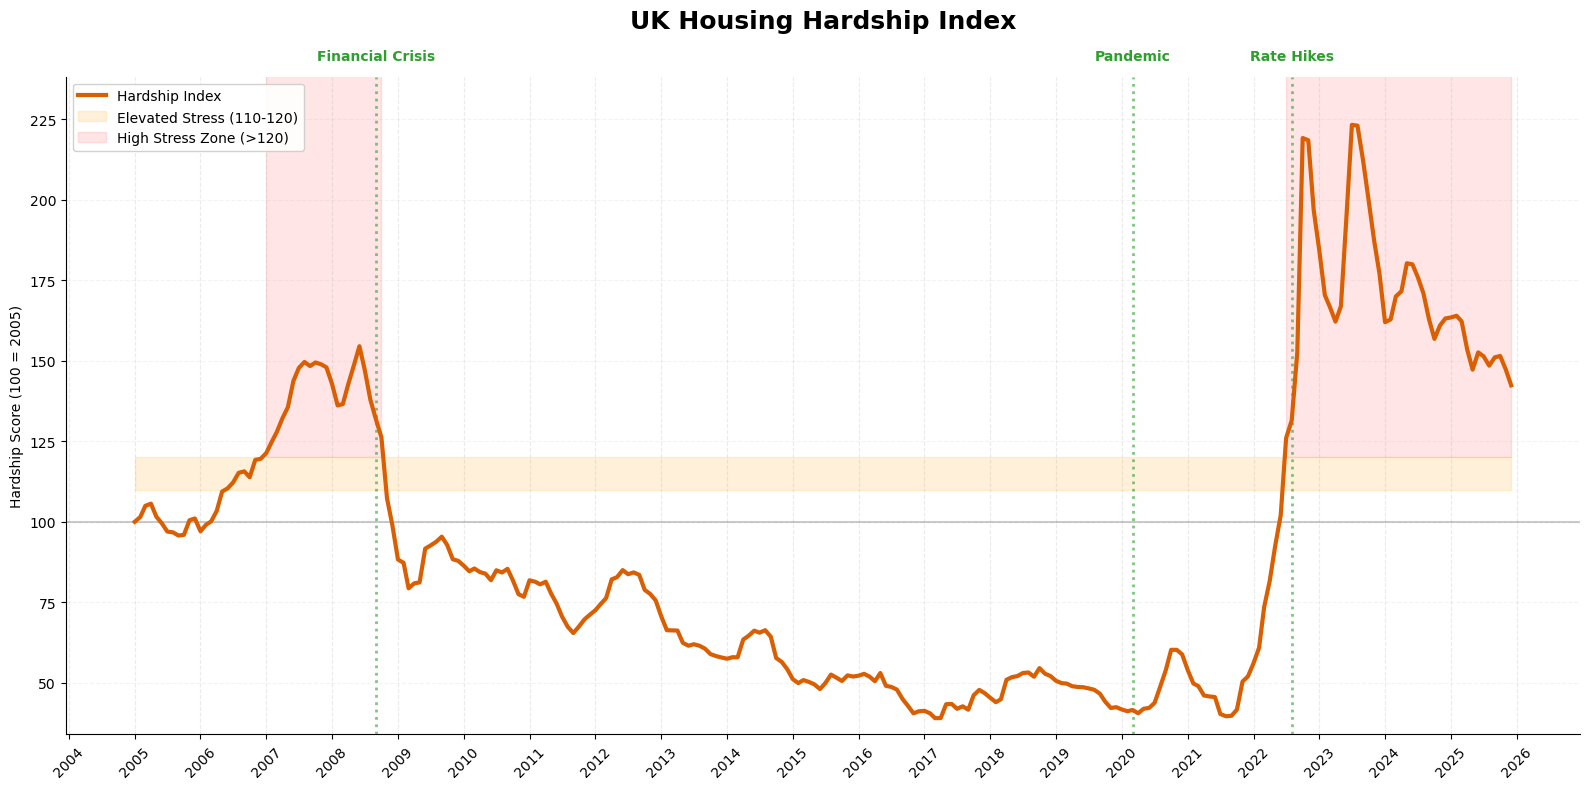

In [20]:
# 1. Calculate the Hardship Index
master_data['hardship_index'] = (master_data['avg_house_price'] * (master_data['rate_2yr'] / 100)) / master_data['real_earnings']

# 2. Normalize it so 2005 equals 100 (as per your Y-axis label)
base_year_val = master_data.loc[master_data['date'].dt.year == 2005, 'hardship_index'].mean()
master_data['hardship_index'] = (master_data['hardship_index'] / base_year_val) * 100

plt.figure(figsize=(16, 8))

# 3. The Core Line
plt.plot(master_data['date'], master_data['hardship_index'], 
         color='#d95f02', linewidth=3, label='Hardship Index', zorder=5)

# 4. Layered Stress Zones
plt.axhline(100, color='black', linestyle='-', alpha=0.2)

plt.fill_between(master_data['date'], 110, 120, 
                 color='orange', alpha=0.15, label='Elevated Stress (110-120)', zorder=2)

plt.fill_between(master_data['date'], 120, master_data['hardship_index'].max() + 20, 
                 where=(master_data['hardship_index'] >= 120), 
                 color='red', alpha=0.1, label='High Stress Zone (>120)', zorder=1)

# 5. Notes
ax = plt.gca()
events = {
    '2008-09-01': 'Financial Crisis',
    '2020-03-01': 'Pandemic',
    '2022-08-01': 'Rate Hikes'
}

for date_str, label in events.items():
    event_date = pd.to_datetime(date_str)
    if event_date > master_data['date'].min():
        # Green dotted vertical line
        plt.axvline(event_date, color='#2ca02c', linestyle=':', alpha=0.6, linewidth=2, zorder=3)
        
        # Horizontal Green Text at the very top (y=1.02)
        plt.text(event_date, 1.02, label, 
                 transform=ax.get_xaxis_transform(), 
                 rotation=0,                  
                 verticalalignment='bottom', 
                 horizontalalignment='center', 
                 fontsize=10, 
                 color='#2ca02c',             
                 fontweight='bold')

# 6. Axis Formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.ylim(master_data['hardship_index'].min() - 5, master_data['hardship_index'].max() + 15)

plt.title('UK Housing Hardship Index', fontsize=18, fontweight='bold', pad=35)
plt.ylabel('Hardship Score (100 = 2005)')
plt.grid(True, axis='y', alpha=0.15)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

**Observation:**

The Hardship Index identifies 2023 as the most difficult period for buyers in 20 years. While the 2010s "Low-Rate Era" kept buyer friction near the 2005 baseline (100) despite rising prices, the recent convergence of record-high prices and high interest rates pushed the index into the "High Stress" zone (>120). This represents the most extreme financial hurdle for prospective homeowners in recent history.

## 11. Statistical Correlation Analysis

To understand the relationships between all key variables and our derived indices simultaneously, we construct a **Pearson Correlation Matrix**. This measures the linear relationship between each pair of variables on a scale from -1 (perfect inverse relationship) to +1 (perfect positive relationship).

| Value | Interpretation |
|-------|---------------|
| > 0.7 | Strong positive correlation |
| 0.3 – 0.7 | Moderate positive correlation |
| < -0.3 | Moderate to strong inverse correlation |

**Variables included:**
* `avg_house_price` — UK average house price
* `price_to_earnings_ratio` — house price as a multiple of annual earnings  
* `real_earnings` — real weekly earnings (£)
* `mortgage_stress_ratio` — monthly repayment as % of monthly earnings
* `rate_2yr` — 2-year fixed mortgage rate
* `hardship_index` — composite affordability score (base 100)

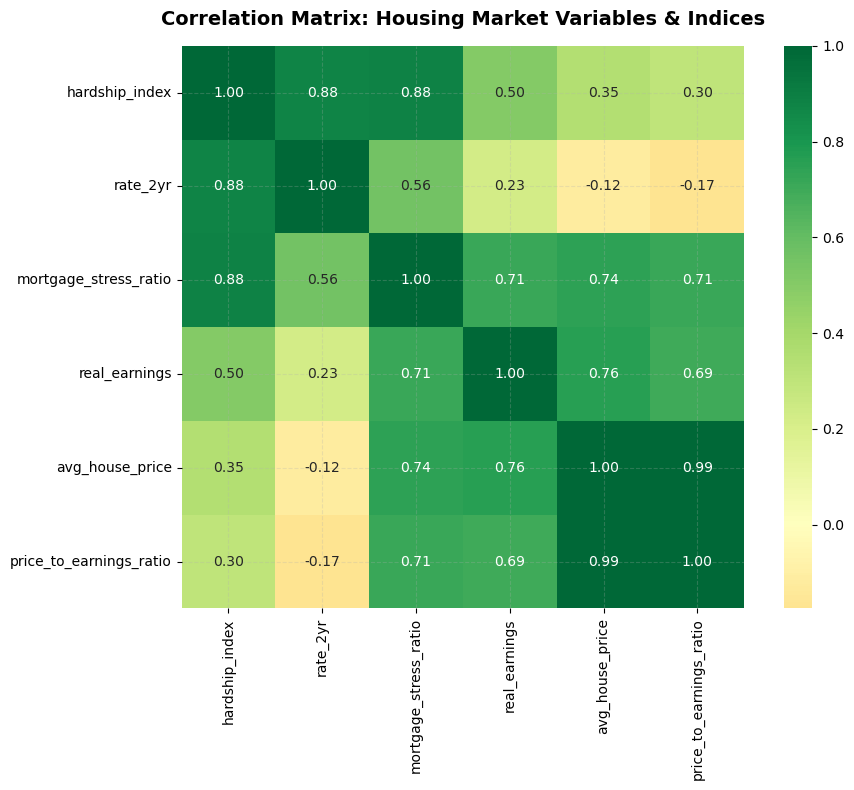

In [18]:
# 1. The key variables for correlation (now including hardship_index)
cols_to_corr = [
    'hardship_index', 
    'rate_2yr',
    'mortgage_stress_ratio', 
    'real_earnings',
    'avg_house_price', 
    'price_to_earnings_ratio'
]

correlation_matrix = master_data[cols_to_corr].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(10, 8)) # Increased figure size slightly to accommodate the extra variable
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', square=True)

plt.title('Correlation Matrix: Housing Market Variables & Indices', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Observation:**

The matrix confirms several key relationships central to this thesis. House prices and the price-to-earnings ratio show a near-perfect positive correlation, confirming that wage growth has not kept pace with price growth over the period. Real earnings show only a moderate correlation with house prices, reinforcing that income growth alone cannot explain the scale of price appreciation seen since 2013.

Crucially, the addition of the `hardship_index` bridges the gap between asset prices and borrowing costs. It demonstrates a strong positive correlation with both the `mortgage_stress_ratio` and `avg_house_price`, validating it as a robust composite metric that accurately tracks overall buyer friction. 

Finally, the strong inverse relationship between `rate_2yr` and the broader affordability metrics reflects the 2010–2021 low-rate era, during which falling rates suppressed monthly borrowing costs even as nominal prices surged to record highs.

## 12. Thesis Conclusion

This analysis demonstrates that UK housing affordability has deteriorated significantly since 2005, driven by a structural divergence between house price growth and real earnings growth. As validated by our correlation analysis, the persistent widening of the price-to-earnings gap cannot be explained by income trends alone. 

Furthermore, the introduction of the Housing Hardship Index reveals a critical nuance: while historically low mortgage rates masked the true cost of this price divergence between 2010 and 2021, the 2022–2023 rate-hike cycle exposed the market's fragility, pushing buyer friction to its highest stress point in two decades. 

Ultimately, while mortgage rate cycles create short-term volatility in affordability, they only treat the symptoms. The evidence points to a market where supply constraints and accumulated demand have driven prices beyond the reach of earnings growth. Meaningful improvement in housing affordability will require structural interventions in housing supply, rather than relying on monetary policy and rate adjustments alone.